<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/analisis_objetivo2_tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# ===================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import shap

# Configuraciones visuales para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
print("Librerías importadas y configuración lista.")

Librerías importadas y configuración lista.


In [ ]:
# 2. CARGA Y PREPARACIÓN DE DATOS
# ===================================================================

# Cargar el dataset
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no se encontró.")
    # Detener la ejecución si el archivo no existe
    raise

# Convertir 'Date' a datetime y establecer como índice
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# --- CORRECCIÓN CRÍTICA: LOOKAHEAD BIAS (FUGA DE DATOS) ---
# El objetivo del día 't' es predecir el retorno que ocurrirá entre 't' y 't+1'.

# Calcular el retorno diario correcto (cambio porcentual del día actual respecto al anterior)
df['GOOGL_Return'] = df['GOOGL_Close'].pct_change()
df['AMZN_Return'] = df['AMZN_Close'].pct_change()

# Crear la variable objetivo (target) desplazándola un día hacia atrás.
# Esto asegura que para la fila del día 't', el objetivo es el retorno del día 't+1'.
df['GOOGL_Target_Return'] = df['GOOGL_Return'].shift(-1)
df['AMZN_Target_Return'] = df['AMZN_Return'].shift(-1)

# Eliminar columnas que no se usarán o que causarían fuga de datos
df = df.drop(columns=['GOOGL_Return_1d', 'AMZN_Return_1d', 'GOOGL_Return', 'AMZN_Return'])

# Eliminar filas con valores NaN resultantes de los cálculos
df.dropna(inplace=True)

print("\nDatos preparados. Corrección de lookahead bias aplicada.")
print("Dimensiones del DataFrame final:", df.shape)
df.head()

Dataset cargado exitosamente.

Datos preparados. Corrección de lookahead bias aplicada.
Dimensiones del DataFrame final: (996, 11)


,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,SP500,NASDAQ,GOOGL_Volatility_20,AMZN_Volatility_20,Inflacion_T5YIE,GOOGL_Target_Return,AMZN_Target_Return
Date,,,,,,,,,,,
2021-01-04,85.895844,159.331497,0.917,26.969999,3700.649902,12698.450195,3.410646,3.841592,1.98,0.008064,0.010004
2021-01-05,86.588524,160.925507,0.955,25.340000,3726.860107,12818.959961,3.410646,3.841592,2.01,-0.009868,-0.024897
2021-01-06,85.734100,156.919006,1.042,25.070000,3748.139893,12740.790039,3.410646,3.841592,2.04,0.029869,0.007577
2021-01-07,88.294868,158.108002,1.071,22.370001,3803.790039,13067.480469,3.410646,3.841592,2.09,0.013239,0.006496
2021-01-08,89.463783,159.134995,1.105,21.559999,3824.679932,13201.980469,3.410646,3.841592,2.07,-0.023106,-0.021519


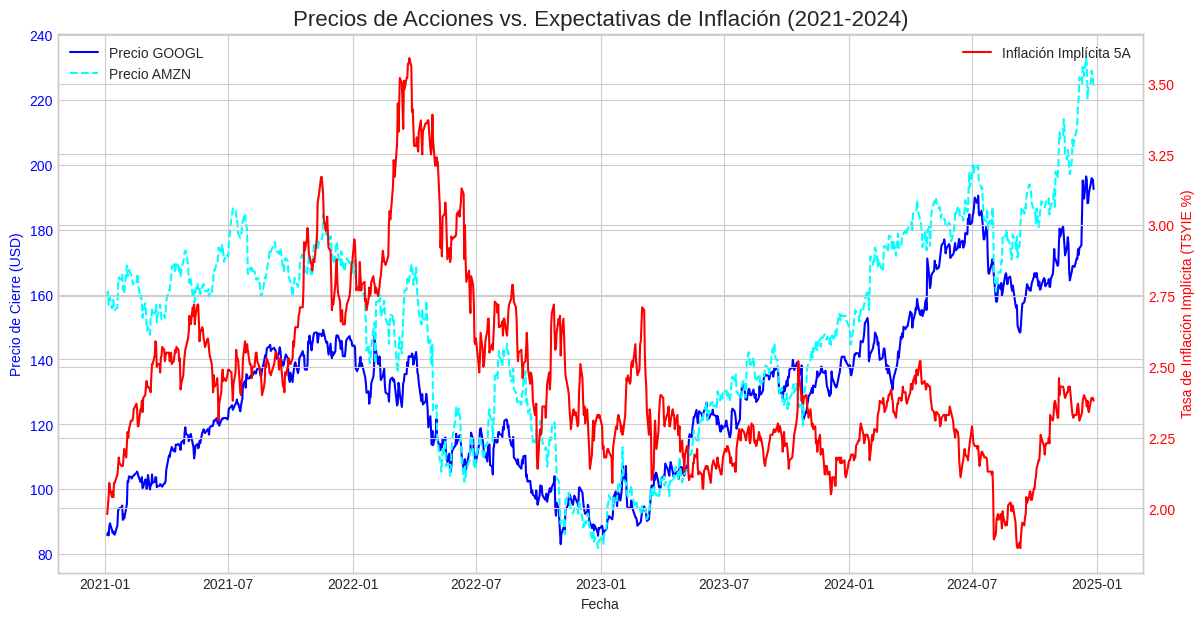

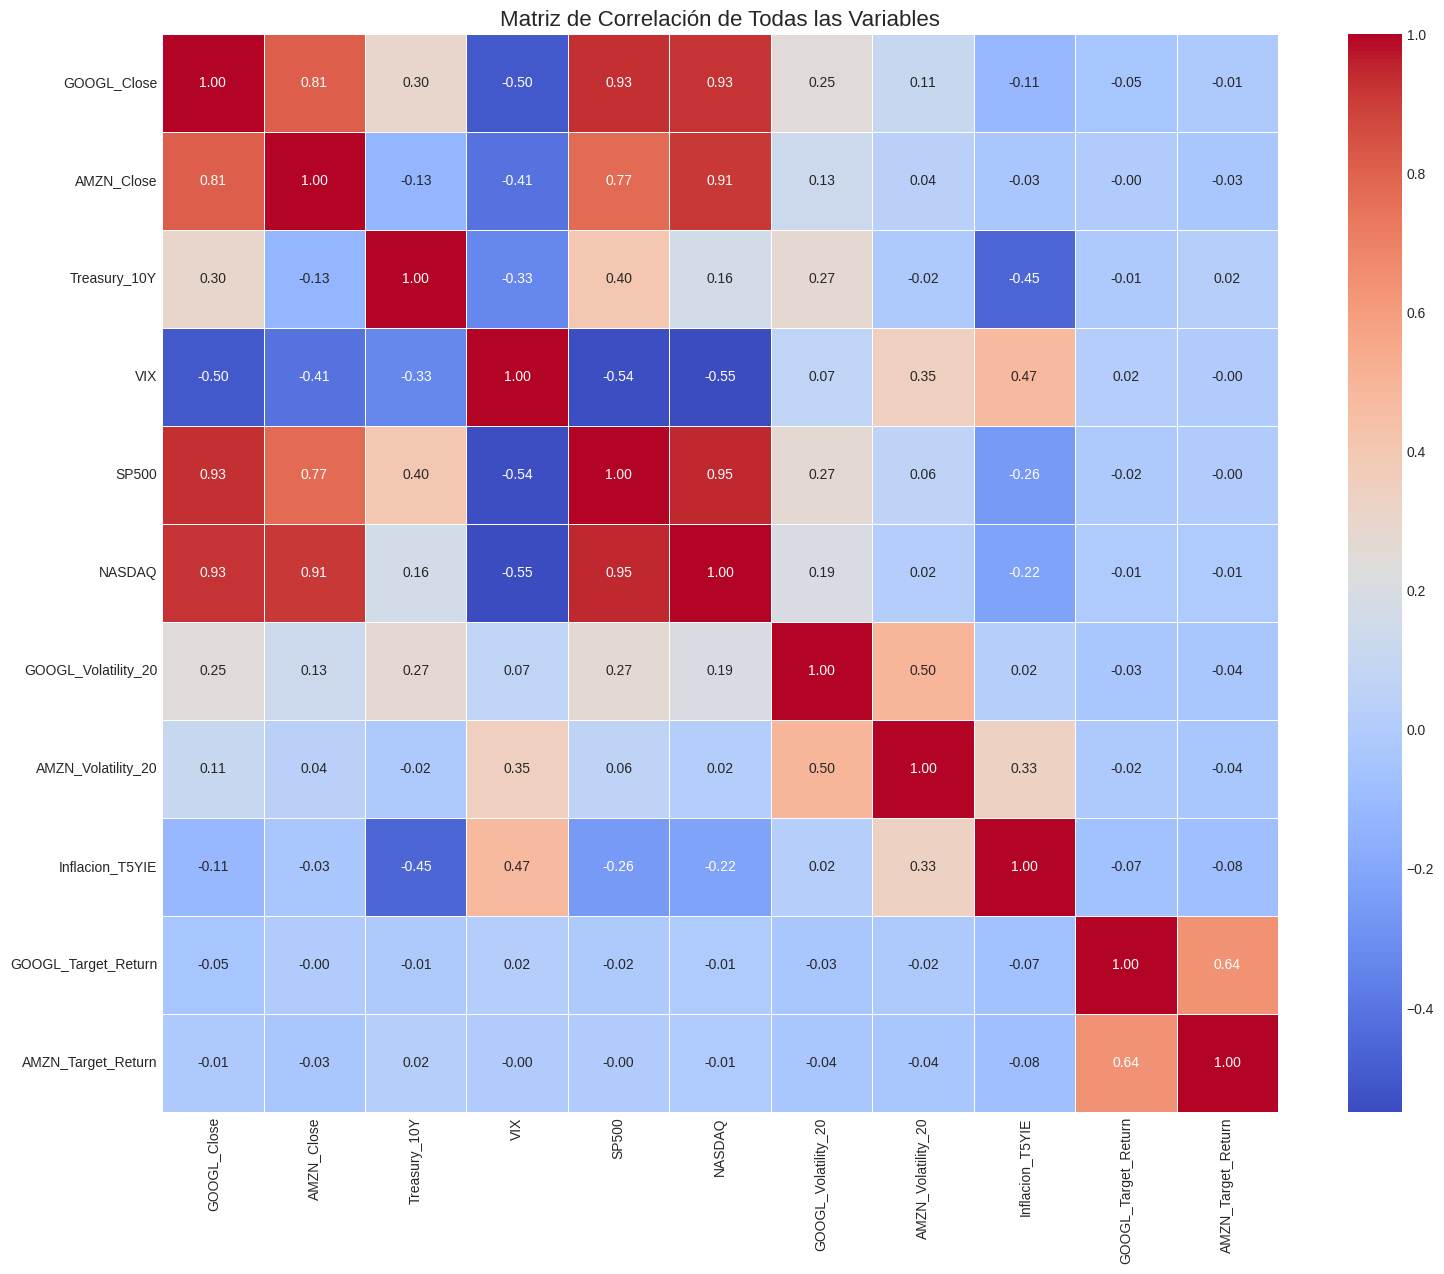

In [ ]:
# 3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ===================================================================

# Gráfico 1: Evolución de Precios vs. Expectativas de Inflación
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.set_title('Precios de Acciones vs. Expectativas de Inflación (2021-2024)', fontsize=16)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio de Cierre (USD)', color='blue')
ax1.plot(df.index, df['GOOGL_Close'], color='blue', label='Precio GOOGL')
ax1.plot(df.index, df['AMZN_Close'], color='cyan', linestyle='--', label='Precio AMZN')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.set_ylabel('Tasa de Inflación Implícita (T5YIE %)', color='red')
ax2.plot(df.index, df['Inflacion_T5YIE'], color='red', label='Inflación Implícita 5A')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')
plt.show()

# Gráfico 2: Matriz de Correlación
correlation_matrix = df.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Todas las Variables', fontsize=16)
plt.show()

In [ ]:
# 4. PREPARACIÓN PARA EL MODELADO
# ===================================================================

# Definir variables predictoras (features) y objetivos (targets)
features = [col for col in df.columns if 'Target' not in col]
X = df[features]
y_googl = df['GOOGL_Target_Return']
y_amzn = df['AMZN_Target_Return']

# División temporal: 80% para entrenamiento, 20% para prueba
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]

# Separar los targets para Google y Amazon
y_train_googl, y_test_googl = y_googl[:split_index], y_googl[split_index:]
y_train_amzn, y_test_amzn = y_amzn[:split_index], y_amzn[split_index:]

print("División de datos completa.")
print(f"Set de entrenamiento: {len(X_train)} filas ({X_train.index.min().date()} a {X_train.index.max().date()})")
print(f"Set de prueba: {len(X_test)} filas ({X_test.index.min().date()} a {X_test.index.max().date()})")

División de datos completa.
Set de entrenamiento: 796 filas (2021-01-04 a 2024-03-11)
Set de prueba: 200 filas (2024-03-12 a 2024-12-27)


In [ ]:
# 5. ENTRENAMIENTO Y EVALUACIÓN DE MODELOS - GOOGLE
# ===================================================================

print("--- Entrenando modelos para GOOGLE ---")

# Modelo Principal: Random Forest
rf_model_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_model_googl.fit(X_train, y_train_googl)
y_pred_rf_googl = rf_model_googl.predict(X_test)

# Modelo Baseline: Regresión Lineal
lr_model_googl = LinearRegression()
lr_model_googl.fit(X_train, y_train_googl)
y_pred_lr_googl = lr_model_googl.predict(X_test)

# Evaluación
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
mse_lr_googl = mean_squared_error(y_test_googl, y_pred_lr_googl)
r2_lr_googl = r2_score(y_test_googl, y_pred_lr_googl)

print("\nResultados de Evaluación para GOOGLE (Set de Prueba):")
print(f"  Random Forest -> MSE: {mse_rf_googl:.6f}, R²: {r2_rf_googl:.4f}, OOB Score: {rf_model_googl.oob_score_:.4f}")
print(f"  Regresión Lineal -> MSE: {mse_lr_googl:.6f}, R²: {r2_lr_googl:.4f}")

--- Entrenando modelos para GOOGLE ---

Resultados de Evaluación para GOOGLE (Set de Prueba):
  Random Forest -> MSE: 0.000693, R²: -1.1950, OOB Score: -0.1063
  Regresión Lineal -> MSE: 0.000346, R²: -0.0945



--- Importancia de Variables para GOOGLE ---
               feature  importance
0  GOOGL_Volatility_20    0.132675
1         Treasury_10Y    0.126902
2   AMZN_Volatility_20    0.121232
3                  VIX    0.113225
4      Inflacion_T5YIE    0.108098
5                SP500    0.105514
6          GOOGL_Close    0.102359
7               NASDAQ    0.097879
8           AMZN_Close    0.092117


/tmp/ipython-input-7-2562860394.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_googl, palette='plasma')


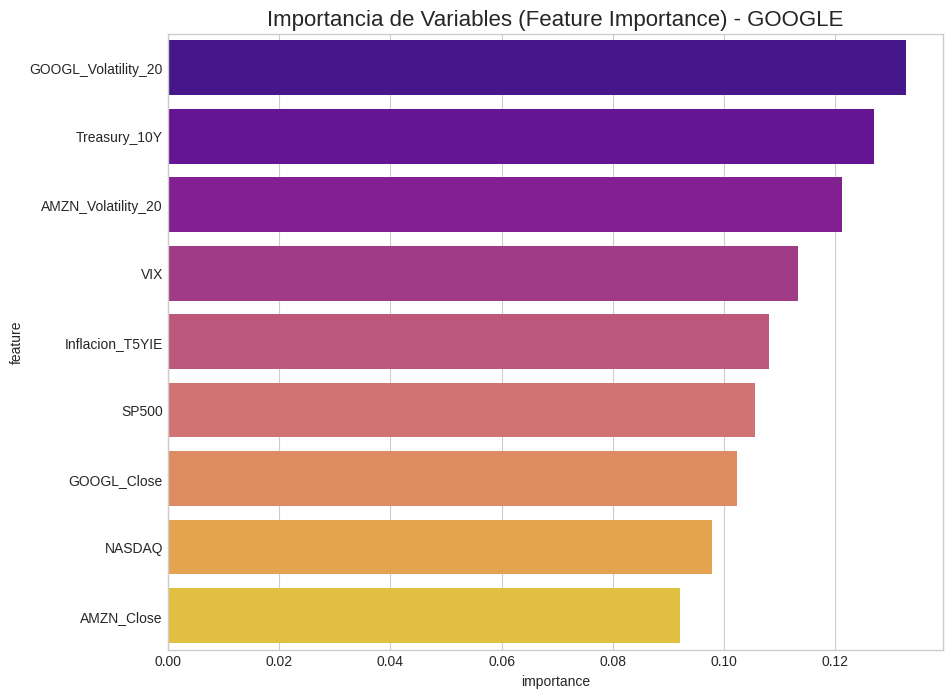


--- Ablation Study para la variable de Inflación - GOOGLE ---
MSE del modelo CON inflación:    0.000693
MSE del modelo SIN inflación:    0.000939
Impacto de la inflación: Al eliminarla, el MSE del modelo cambió en un 35.44%.


In [ ]:
# 6. ANÁLISIS DE INFLUENCIA DE LA INFLACIÓN - GOOGLE
# ===================================================================

# 6.1. Feature Importance
feature_importances_googl = pd.DataFrame({
    'feature': features,
    'importance': rf_model_googl.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n--- Importancia de Variables para GOOGLE ---")
print(feature_importances_googl)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_googl, palette='plasma')
plt.title('Importancia de Variables (Feature Importance) - GOOGLE', fontsize=16)
plt.show()

# 6.2. Ablation Study
print("\n--- Ablation Study para la variable de Inflación - GOOGLE ---")
features_no_inflation = [f for f in features if f != 'Inflacion_T5YIE']
X_train_no_inf = X_train[features_no_inflation]
X_test_no_inf = X_test[features_no_inflation]

rf_model_no_inf_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_no_inf_googl.fit(X_train_no_inf, y_train_googl)
y_pred_no_inf_googl = rf_model_no_inf_googl.predict(X_test_no_inf)
mse_no_inf_googl = mean_squared_error(y_test_googl, y_pred_no_inf_googl)

print(f"MSE del modelo CON inflación:    {mse_rf_googl:.6f}")
print(f"MSE del modelo SIN inflación:    {mse_no_inf_googl:.6f}")
impacto_mse = ((mse_no_inf_googl - mse_rf_googl) / mse_rf_googl) * 100
print(f"Impacto de la inflación: Al eliminarla, el MSE del modelo cambió en un {impacto_mse:.2f}%.")


Generando PDP para GOOGLE...


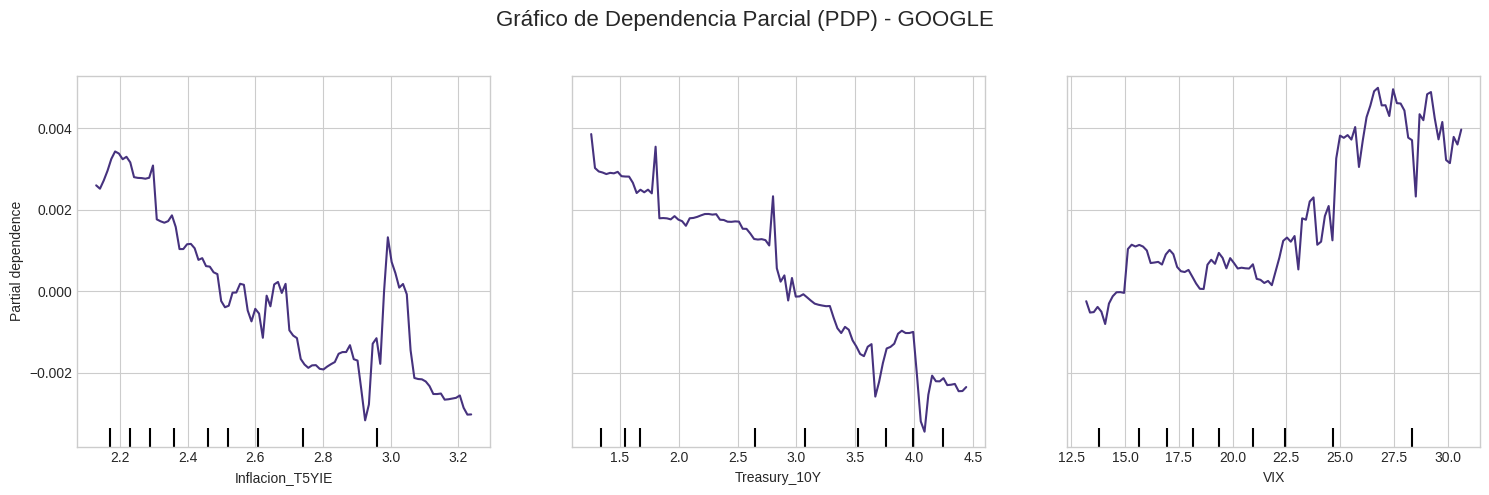


Calculando y mostrando gráficos SHAP para GOOGLE...


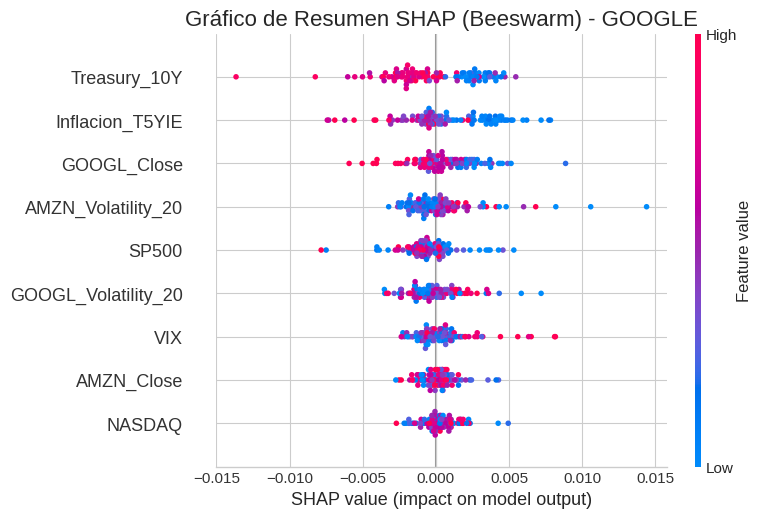

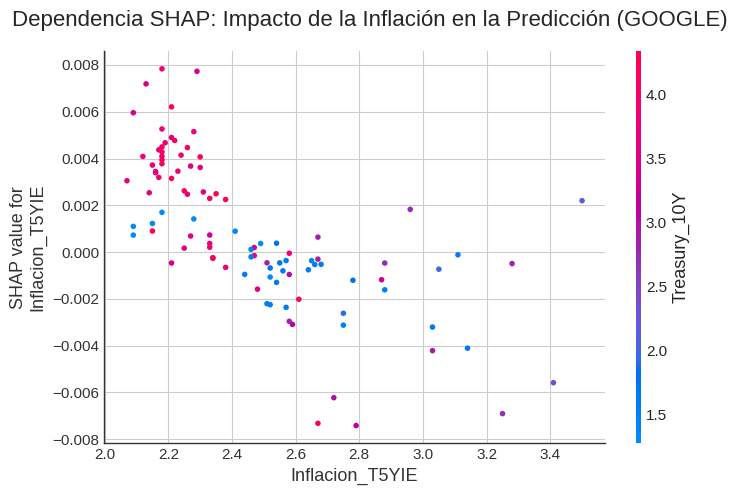

In [ ]:
# 7. INTERPRETABILIDAD AVANZADA (PDP & SHAP) - GOOGLE
# ===================================================================

# 7.1. Partial Dependence Plots (PDP)
print("\nGenerando PDP para GOOGLE...")
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(
    estimator=rf_model_googl,
    X=X_train,
    features=['Inflacion_T5YIE', 'Treasury_10Y', 'VIX'],
    ax=ax
)
plt.suptitle('Gráfico de Dependencia Parcial (PDP) - GOOGLE', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 7.2. SHAP Analysis
print("\nCalculando y mostrando gráficos SHAP para GOOGLE...")
X_sample_googl = X_train.sample(100, random_state=1)
explainer_googl = shap.TreeExplainer(rf_model_googl)
shap_values_googl = explainer_googl.shap_values(X_sample_googl)

# SHAP Summary Plot
shap.summary_plot(shap_values_googl, X_sample_googl, show=False)
plt.title("Gráfico de Resumen SHAP (Beeswarm) - GOOGLE", fontsize=16)
plt.show()

# SHAP Dependence Plot
shap.dependence_plot("Inflacion_T5YIE", shap_values_googl, X_sample_googl, interaction_index="Treasury_10Y", show=False)
plt.suptitle("Dependencia SHAP: Impacto de la Inflación en la Predicción (GOOGLE)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# 8. ENTRENAMIENTO Y EVALUACIÓN DE MODELOS - AMAZON
# ===================================================================

print("--- Entrenando modelos para AMAZON ---")

# Modelo Principal: Random Forest
rf_model_amzn = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_model_amzn.fit(X_train, y_train_amzn)
y_pred_rf_amzn = rf_model_amzn.predict(X_test)

# Modelo Baseline: Regresión Lineal
lr_model_amzn = LinearRegression()
lr_model_amzn.fit(X_train, y_train_amzn)
y_pred_lr_amzn = lr_model_amzn.predict(X_test)

# Evaluación
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
mse_lr_amzn = mean_squared_error(y_test_amzn, y_pred_lr_amzn)
r2_lr_amzn = r2_score(y_test_amzn, y_pred_lr_amzn)

print("\nResultados de Evaluación para AMAZON (Set de Prueba):")
print(f"  Random Forest -> MSE: {mse_rf_amzn:.6f}, R²: {r2_rf_amzn:.4f}, OOB Score: {rf_model_amzn.oob_score_:.4f}")
print(f"  Regresión Lineal -> MSE: {mse_lr_amzn:.6f}, R²: {r2_lr_amzn:.4f}")

--- Entrenando modelos para AMAZON ---

Resultados de Evaluación para AMAZON (Set de Prueba):
  Random Forest -> MSE: 0.000411, R²: -0.3185, OOB Score: -0.0444
  Regresión Lineal -> MSE: 0.000330, R²: -0.0580



--- Importancia de Variables para AMAZON ---
               feature  importance
0  GOOGL_Volatility_20    0.135062
1   AMZN_Volatility_20    0.130592
2         Treasury_10Y    0.120197
3               NASDAQ    0.118639
4      Inflacion_T5YIE    0.109389
5                  VIX    0.105838
6           AMZN_Close    0.103180
7          GOOGL_Close    0.102150
8                SP500    0.074954


/tmp/ipython-input-10-2847120533.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_amzn, palette='cividis')


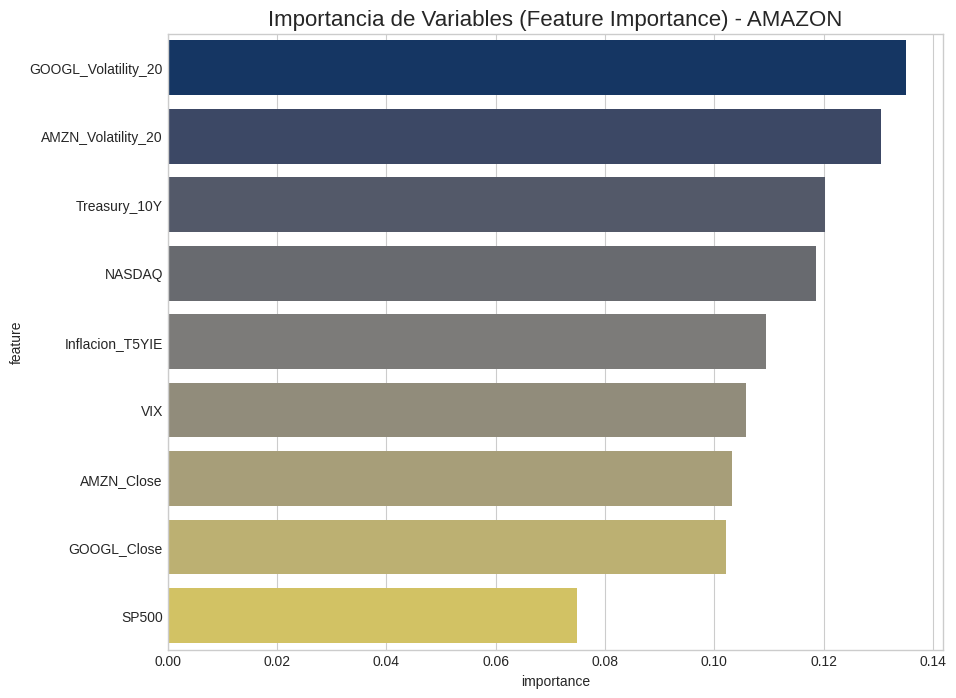


--- Ablation Study para la variable de Inflación - AMAZON ---
MSE del modelo CON inflación:    0.000411
MSE del modelo SIN inflación:    0.000759
Impacto de la inflación: Al eliminarla, el MSE del modelo cambió en un 84.38%.


In [ ]:
# 9. ANÁLISIS DE INFLUENCIA DE LA INFLACIÓN - AMAZON
# ===================================================================

# 9.1. Feature Importance
feature_importances_amzn = pd.DataFrame({
    'feature': features,
    'importance': rf_model_amzn.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n--- Importancia de Variables para AMAZON ---")
print(feature_importances_amzn)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_amzn, palette='cividis')
plt.title('Importancia de Variables (Feature Importance) - AMAZON', fontsize=16)
plt.show()

# 9.2. Ablation Study
print("\n--- Ablation Study para la variable de Inflación - AMAZON ---")
features_no_inflation = [f for f in features if f != 'Inflacion_T5YIE']
X_train_no_inf = X_train[features_no_inflation]
X_test_no_inf = X_test[features_no_inflation]

rf_model_no_inf_amzn = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_no_inf_amzn.fit(X_train_no_inf, y_train_amzn)
y_pred_no_inf_amzn = rf_model_no_inf_amzn.predict(X_test_no_inf)
mse_no_inf_amzn = mean_squared_error(y_test_amzn, y_pred_no_inf_amzn)

print(f"MSE del modelo CON inflación:    {mse_rf_amzn:.6f}")
print(f"MSE del modelo SIN inflación:    {mse_no_inf_amzn:.6f}")
impacto_mse_amzn = ((mse_no_inf_amzn - mse_rf_amzn) / mse_rf_amzn) * 100
print(f"Impacto de la inflación: Al eliminarla, el MSE del modelo cambió en un {impacto_mse_amzn:.2f}%.")


Generando PDP para AMAZON...


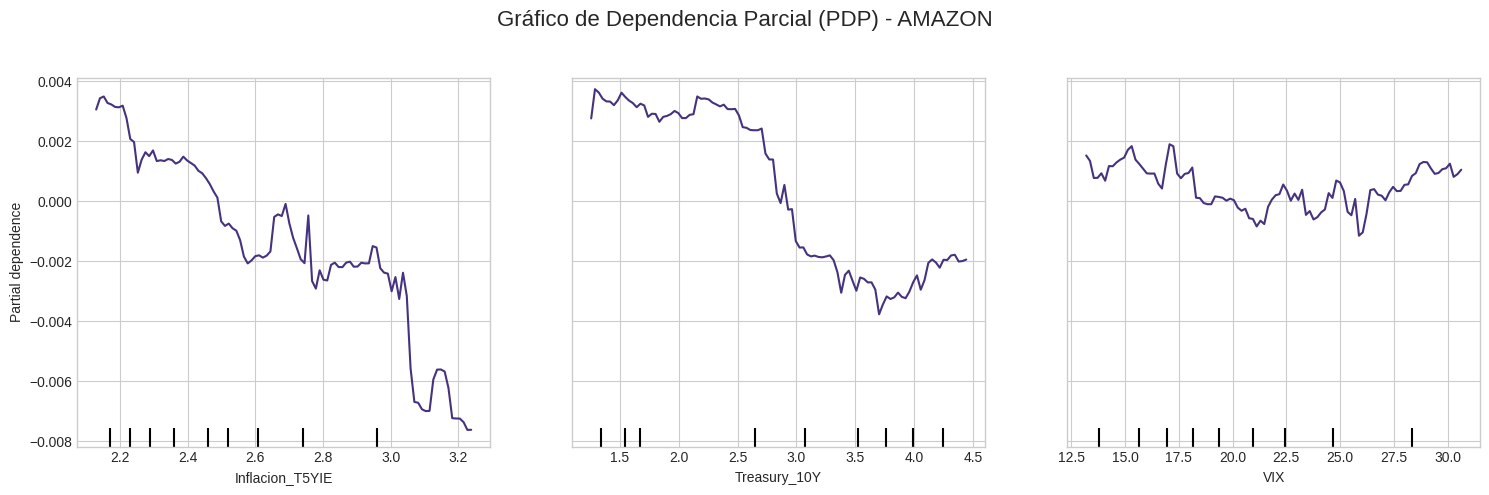


Calculando y mostrando gráficos SHAP para AMAZON...


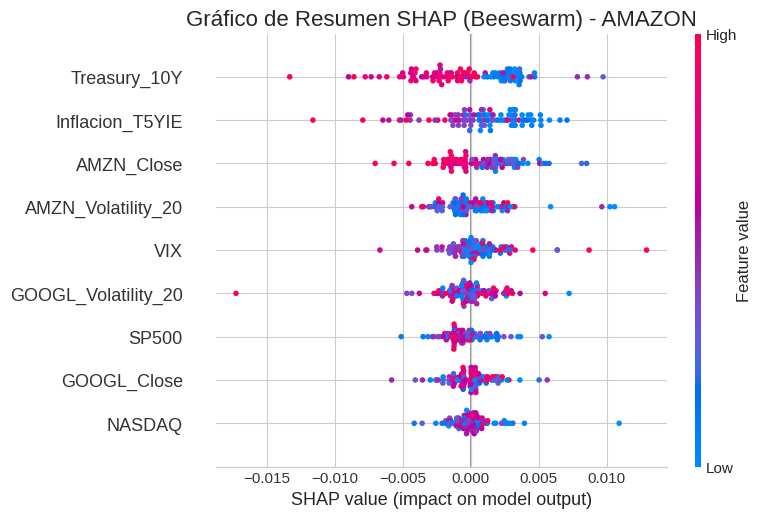

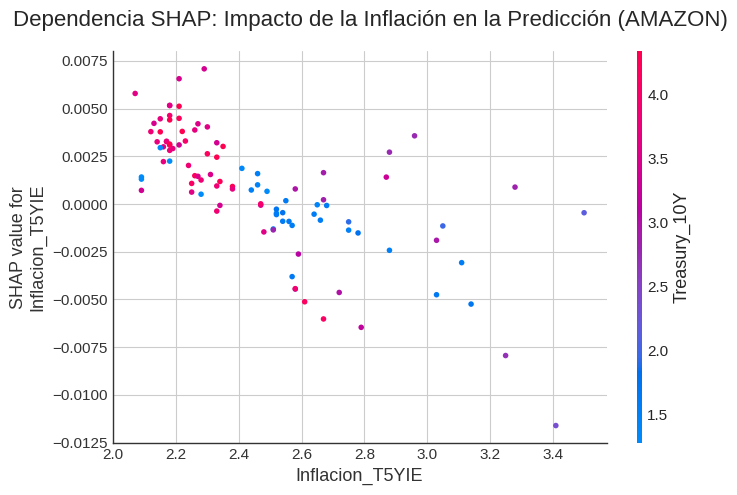

In [ ]:
# 10. INTERPRETABILIDAD AVANZADA (PDP & SHAP) - AMAZON
# ===================================================================

# 10.1. Partial Dependence Plots (PDP)
print("\nGenerando PDP para AMAZON...")
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(
    estimator=rf_model_amzn,
    X=X_train,
    features=['Inflacion_T5YIE', 'Treasury_10Y', 'VIX'],
    ax=ax
)
plt.suptitle('Gráfico de Dependencia Parcial (PDP) - AMAZON', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 10.2. SHAP Analysis
print("\nCalculando y mostrando gráficos SHAP para AMAZON...")
X_sample_amzn = X_train.sample(100, random_state=1)
explainer_amzn = shap.TreeExplainer(rf_model_amzn)
shap_values_amzn = explainer_amzn.shap_values(X_sample_amzn)

# SHAP Summary Plot
shap.summary_plot(shap_values_amzn, X_sample_amzn, show=False)
plt.title("Gráfico de Resumen SHAP (Beeswarm) - AMAZON", fontsize=16)
plt.show()

# SHAP Dependence Plot
shap.dependence_plot("Inflacion_T5YIE", shap_values_amzn, X_sample_amzn, interaction_index="Treasury_10Y", show=False)
plt.suptitle("Dependencia SHAP: Impacto de la Inflación en la Predicción (AMAZON)", fontsize=16)
plt.tight_layout()
plt.show()

--- 1. Carga y Preparación de Datos ---
Datos cargados y preparados. Dimensión del DataFrame: (996, 11)
Columnas disponibles: ['GOOGL_Close', 'AMZN_Close', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'GOOGL_Volatility_20', 'AMZN_Volatility_20', 'Inflacion_T5YIE', 'GOOGL_Target_Return', 'AMZN_Target_Return']

--- 2. Análisis Exploratorio de Datos (EDA) ---


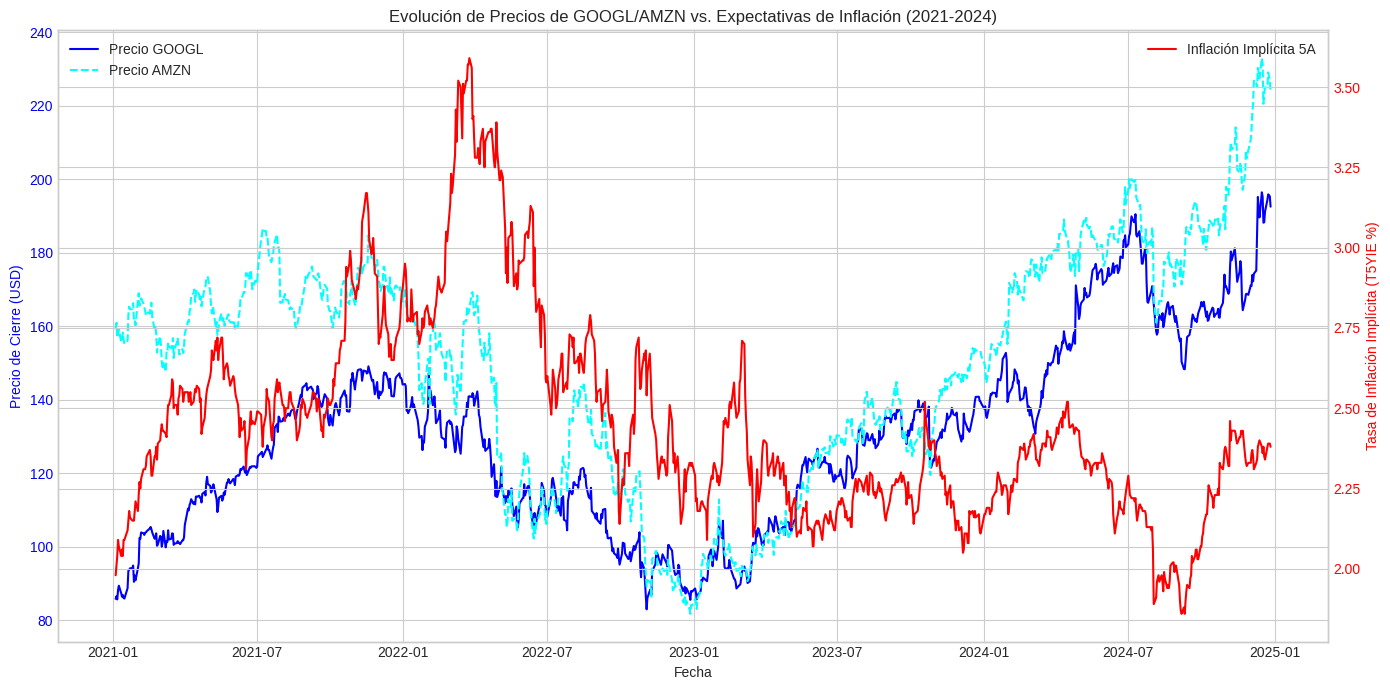

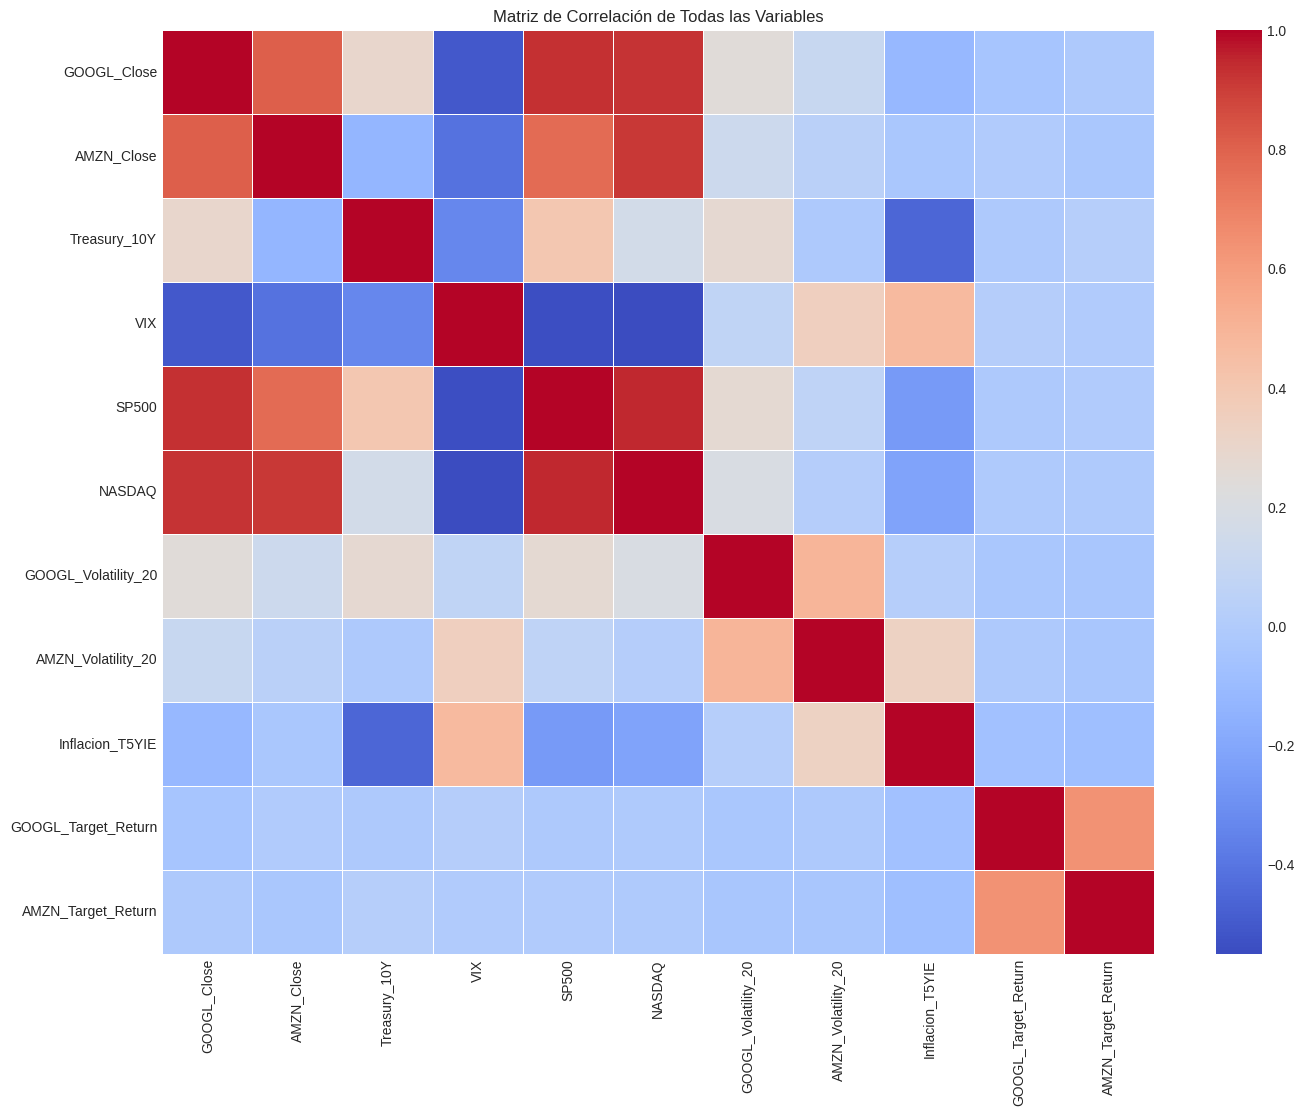

Correlación de variables con el retorno objetivo de GOOGL:
GOOGL_Target_Return    1.000000
AMZN_Target_Return     0.639186
VIX                    0.017910
AMZN_Close            -0.003008
NASDAQ                -0.009911
Treasury_10Y          -0.012483
AMZN_Volatility_20    -0.016999
SP500                 -0.017082
GOOGL_Volatility_20   -0.031899
GOOGL_Close           -0.046807
Inflacion_T5YIE       -0.066022
Name: GOOGL_Target_Return, dtype: float64

Correlación de variables con el retorno objetivo de AMZN:
AMZN_Target_Return     1.000000
GOOGL_Target_Return    0.639186
Treasury_10Y           0.022116
SP500                 -0.001906
VIX                   -0.002652
NASDAQ                -0.008389
GOOGL_Close           -0.014717
AMZN_Close            -0.033967
GOOGL_Volatility_20   -0.036184
AMZN_Volatility_20    -0.040529
Inflacion_T5YIE       -0.080893
Name: AMZN_Target_Return, dtype: float64

--- 3. Entrenamiento y Evaluación de Modelos ---

Análisis para GOOGL:
Tamaño del set de entre

/tmp/ipython-input-12-2451067371.py:174: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')


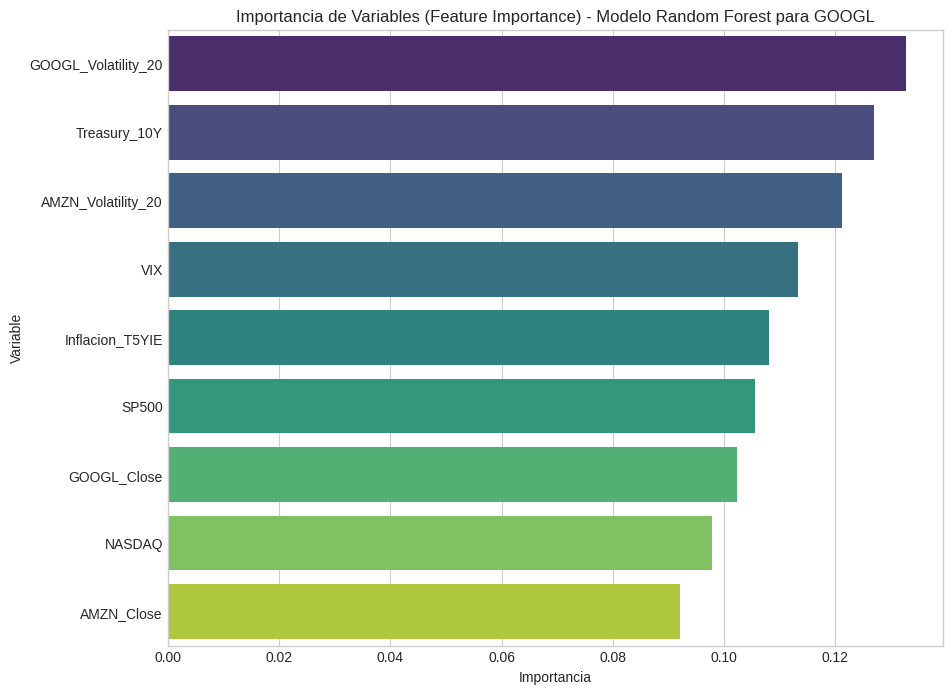


--- 4.2. Ablation Study (Estudio de Contribución Marginal) ---
Comparación de rendimiento del modelo CON y SIN la variable de inflación:
  MSE con inflación:    0.000693
  MSE sin inflación:    0.000939
Conclusión: La variable de inflación mejora el modelo. Al quitarla, el MSE aumentó en 35.44%.

--- 4.3. Gráficos de Dependencia Parcial (PDP) ---
Generando PDP para la variable de inflación. Esto puede tardar un momento...


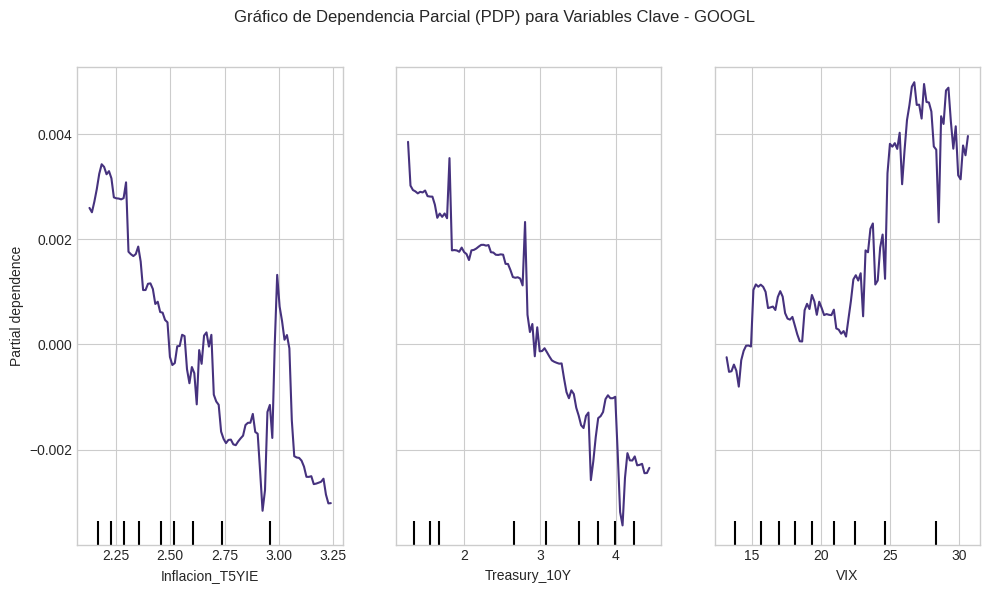


--- 4.4. Análisis con SHAP ---
Calculando valores SHAP. Esto es computacionalmente intensivo...
Generando gráfico de resumen SHAP...


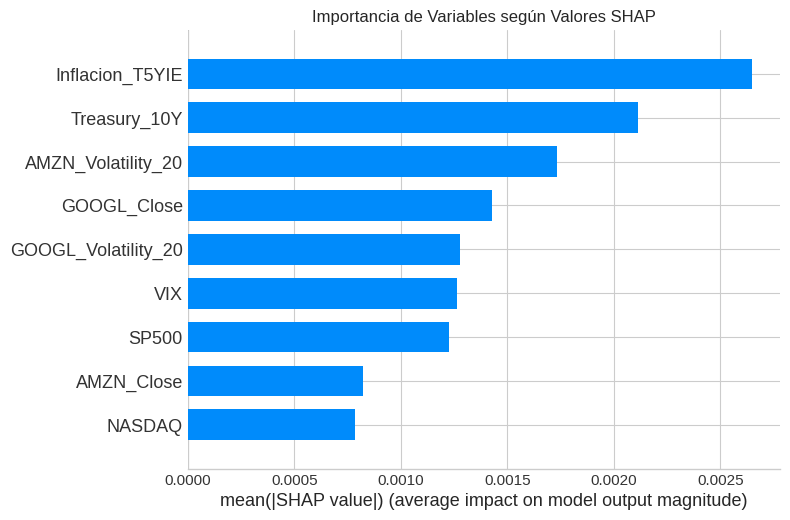

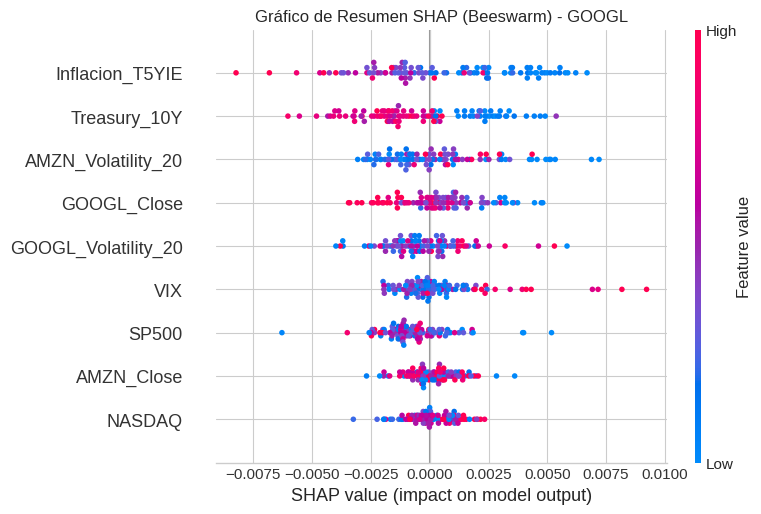

Generando gráfico de dependencia SHAP para la inflación...


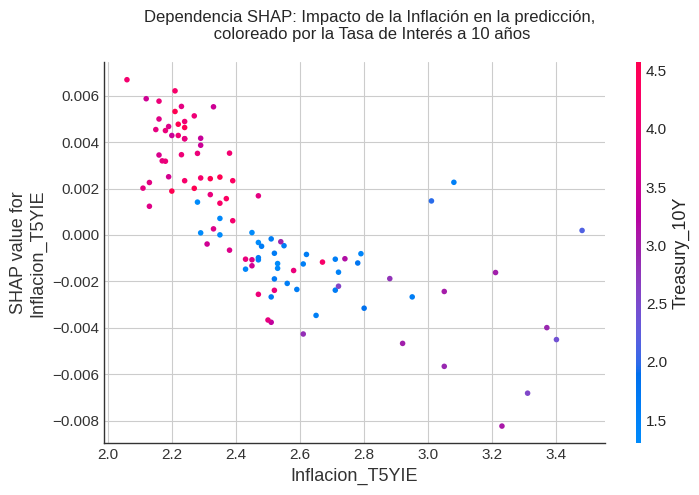


--- 4.5. Análisis por Regímenes de Mercado ---
MSE en régimen de Alta Volatilidad (VIX > 20): 0.000482
MSE en régimen de Baja Volatilidad (VIX <= 20): 0.000723

Ablation study en régimen de Alta Inflación (Inflación > 2.39%):
  MSE con inflación:    0.000855
  MSE sin inflación:    0.001016
  Impacto de quitar la inflación en este régimen: Aumento del MSE en 18.87%.

--- Fin del Análisis para GOOGL ---

NOTA: El mismo análisis detallado se puede replicar para AMZN cambiando la variable objetivo 'y'.


In [ ]:
# -*- coding: utf-8 -*-
"""
Script Completo para el Análisis de la Tesis:
"Uso de modelos supervisados en la predicción de precios de acciones de Google y Amazon"

Este script cubre:
1. Carga y Preparación de Datos (Corrigiendo el Lookahead Bias).
2. Análisis Exploratorio de Datos (EDA) enfocado en la inflación.
3. Entrenamiento y Evaluación de Modelos (Random Forest y Baseline).
4. Análisis Detallado del Objetivo Específico 2: Influencia de la Inflación.
    - Feature Importance.
    - Ablation Study (Estudio de Contribución Marginal).
    - Partial Dependence Plots (PDP).
    - SHAP (SHapley Additive exPlanations).
    - Análisis por Regímenes de Mercado.

Autor: Asistente de IA basado en la tesis de [Nombres de los autores]
Fecha: [Fecha Actual]
"""

# 1. IMPORTACIÓN DE LIBRERÍAS
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import shap

# Establecer estilo para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# 2. CARGA Y PREPARACIÓN DE DATOS
# ---------------------------------------------------------------------------
print("--- 1. Carga y Preparación de Datos ---")

# Cargar el dataset
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no se encontró.")
    print("Asegúrate de que el archivo esté en el mismo directorio que este script.")
    exit()

# Convertir la columna 'Date' a formato datetime y establecerla como índice
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# --- CORRECCIÓN CRÍTICA: LOOKAHEAD BIAS (FUGA DE DATOS) ---
# El objetivo de un modelo en el día 't' es predecir el retorno del *siguiente* día (entre 't' y 't+1').
# Calculamos el retorno como el cambio porcentual y luego lo desplazamos hacia atrás (-1).

# Calcular el retorno diario correcto
df['GOOGL_Return'] = df['GOOGL_Close'].pct_change()
df['AMZN_Return'] = df['AMZN_Close'].pct_change()

# Crear la variable objetivo (target) desplazada
# Esta será la variable que intentaremos predecir
df['GOOGL_Target_Return'] = df['GOOGL_Return'].shift(-1)
df['AMZN_Target_Return'] = df['AMZN_Return'].shift(-1)

# Eliminar las columnas originales de retorno para evitar confusión y fuga de datos
df = df.drop(columns=['GOOGL_Return_1d', 'AMZN_Return_1d', 'GOOGL_Return', 'AMZN_Return'])

# Eliminar filas con valores NaN (la primera por el pct_change, la última por el shift)
df.dropna(inplace=True)

print("Datos cargados y preparados. Dimensión del DataFrame:", df.shape)
print("Columnas disponibles:", df.columns.tolist())

# 3. ANÁLISIS EXPLORATORIO DE DATOS (EDA) - Enfocado en Inflación
# ---------------------------------------------------------------------------
print("\n--- 2. Análisis Exploratorio de Datos (EDA) ---")

# Visualización Temporal de la Inflación vs. Precios
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio de Cierre (USD)', color='blue')
ax1.plot(df.index, df['GOOGL_Close'], color='blue', label='Precio GOOGL')
ax1.plot(df.index, df['AMZN_Close'], color='cyan', linestyle='--', label='Precio AMZN')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # Crear un segundo eje Y que comparte el mismo eje X
ax2.set_ylabel('Tasa de Inflación Implícita (T5YIE %)', color='red')
ax2.plot(df.index, df['Inflacion_T5YIE'], color='red', label='Inflación Implícita 5A')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Evolución de Precios de GOOGL/AMZN vs. Expectativas de Inflación (2021-2024)')
fig.tight_layout()
plt.show()

# Matriz de Correlación
correlation_matrix = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=.5)
plt.title('Matriz de Correlación de Todas las Variables')
plt.show()

# Correlación específica con la variable objetivo
print("Correlación de variables con el retorno objetivo de GOOGL:")
print(correlation_matrix['GOOGL_Target_Return'].sort_values(ascending=False))
print("\nCorrelación de variables con el retorno objetivo de AMZN:")
print(correlation_matrix['AMZN_Target_Return'].sort_values(ascending=False))


# 4. DEFINICIÓN Y ENTRENAMIENTO DE MODELOS
# ---------------------------------------------------------------------------
print("\n--- 3. Entrenamiento y Evaluación de Modelos ---")

# --- ANÁLISIS PARA GOOGLE (GOOGL) ---

# Definir variables predictoras (features) y objetivo (target)
features = [col for col in df.columns if 'Target' not in col]
X = df[features]
y_googl = df['GOOGL_Target_Return']

# Dividir los datos en entrenamiento y prueba (respetando la serie temporal)
# Se usará el 80% de los datos para entrenar y el 20% para probar
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train_googl, y_test_googl = y_googl[:split_index], y_googl[split_index:]

print(f"\nAnálisis para GOOGL:")
print(f"Tamaño del set de entrenamiento: {len(X_train)}")
print(f"Tamaño del set de prueba: {len(X_test)}")

# Modelo 1: Random Forest (Modelo principal)
rf_model_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_model_googl.fit(X_train, y_train_googl)
y_pred_rf_googl = rf_model_googl.predict(X_test)

# Modelo 2: Regresión Lineal (Baseline simple)
lr_model_googl = LinearRegression()
lr_model_googl.fit(X_train, y_train_googl)
y_pred_lr_googl = lr_model_googl.predict(X_test)

# Evaluación de los modelos
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)

mse_lr_googl = mean_squared_error(y_test_googl, y_pred_lr_googl)
r2_lr_googl = r2_score(y_test_googl, y_pred_lr_googl)

print("\nResultados de Evaluación para GOOGL (Set de Prueba):")
print(f"  Random Forest -> MSE: {mse_rf_googl:.6f}, R²: {r2_rf_googl:.4f}")
print(f"  Regresión Lineal -> MSE: {mse_lr_googl:.6f}, R²: {r2_lr_googl:.4f}")
print(f"  OOB Score del Random Forest (estimación de rendimiento): {rf_model_googl.oob_score_:.4f}")
print("(Nota: Un R² negativo indica que el modelo es peor que simplemente predecir la media)")


# 5. ANÁLISIS DETALLADO DE LA INFLUENCIA DE LA INFLACIÓN (OBJETIVO 2)
# ---------------------------------------------------------------------------
print("\n--- 4. Análisis Detallado del Objetivo Específico 2: Influencia de la Inflación en GOOGL ---")

# --- 5.1. Análisis de Importancia de Variables (Feature Importance) ---
print("\n--- 4.1. Importancia de Variables (Feature Importance) ---")
feature_importances = pd.DataFrame({
    'feature': features,
    'importance': rf_model_googl.feature_importances_
}).sort_values('importance', ascending=False)

print("Ranking de importancia de variables para predecir retornos de GOOGL:")
print(feature_importances)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')
plt.title('Importancia de Variables (Feature Importance) - Modelo Random Forest para GOOGL')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

# --- 5.2. Ablation Study (Contribución Marginal de la Inflación) ---
print("\n--- 4.2. Ablation Study (Estudio de Contribución Marginal) ---")
features_no_inflation = [f for f in features if f != 'Inflacion_T5YIE']
X_train_no_inf = X_train[features_no_inflation]
X_test_no_inf = X_test[features_no_inflation]

# Entrenar modelo sin la variable de inflación
rf_model_no_inf_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_no_inf_googl.fit(X_train_no_inf, y_train_googl)
y_pred_no_inf_googl = rf_model_no_inf_googl.predict(X_test_no_inf)
mse_no_inf_googl = mean_squared_error(y_test_googl, y_pred_no_inf_googl)
r2_no_inf_googl = r2_score(y_test_googl, y_pred_no_inf_googl)

print("Comparación de rendimiento del modelo CON y SIN la variable de inflación:")
print(f"  MSE con inflación:    {mse_rf_googl:.6f}")
print(f"  MSE sin inflación:    {mse_no_inf_googl:.6f}")

# Calcular el impacto porcentual en el error
if mse_rf_googl != 0:
    impacto_mse = ((mse_no_inf_googl - mse_rf_googl) / mse_rf_googl) * 100
    if impacto_mse > 0:
        print(f"Conclusión: La variable de inflación mejora el modelo. Al quitarla, el MSE aumentó en {impacto_mse:.2f}%.")
    else:
        print(f"Conclusión: La variable de inflación no parece mejorar el modelo. Al quitarla, el MSE disminuyó en {-impacto_mse:.2f}%.")

# --- 5.3. Gráficos de Dependencia Parcial (PDP) ---
print("\n--- 4.3. Gráficos de Dependencia Parcial (PDP) ---")
print("Generando PDP para la variable de inflación. Esto puede tardar un momento...")

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    estimator=rf_model_googl,
    X=X_train,
    features=['Inflacion_T5YIE', 'Treasury_10Y', 'VIX'],
    ax=ax
)
plt.suptitle('Gráfico de Dependencia Parcial (PDP) para Variables Clave - GOOGL')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- 5.4. Análisis con SHAP (SHapley Additive exPlanations) ---
print("\n--- 4.4. Análisis con SHAP ---")
print("Calculando valores SHAP. Esto es computacionalmente intensivo...")

# Usar un subconjunto de los datos para calcular SHAP más rápido si el dataset es muy grande
X_sample = X_train.sample(100, random_state=42) if len(X_train) > 100 else X_train

explainer = shap.TreeExplainer(rf_model_googl)
shap_values = explainer.shap_values(X_sample)

# Gráfico de resumen (beeswarm plot)
print("Generando gráfico de resumen SHAP...")
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Importancia de Variables según Valores SHAP")
plt.show()

shap.summary_plot(shap_values, X_sample, show=False)
plt.title("Gráfico de Resumen SHAP (Beeswarm) - GOOGL")
plt.show()

# Gráfico de dependencia SHAP para la inflación
print("Generando gráfico de dependencia SHAP para la inflación...")
shap.dependence_plot("Inflacion_T5YIE", shap_values, X_sample, interaction_index="Treasury_10Y", show=False)
plt.suptitle("Dependencia SHAP: Impacto de la Inflación en la predicción,\n coloreado por la Tasa de Interés a 10 años")
plt.tight_layout()
plt.show()

# --- 5.5. Análisis por Regímenes de Mercado ---
print("\n--- 4.5. Análisis por Regímenes de Mercado ---")
# Definir regímenes en el conjunto de prueba
vix_threshold = 20
inflation_threshold = df['Inflacion_T5YIE'].median()

# Régimen de Alta Volatilidad (VIX > 20)
X_test_high_vix = X_test[X_test['VIX'] > vix_threshold]
y_test_high_vix = y_test_googl.loc[X_test_high_vix.index]

# Régimen de Baja Volatilidad (VIX <= 20)
X_test_low_vix = X_test[X_test['VIX'] <= vix_threshold]
y_test_low_vix = y_test_googl.loc[X_test_low_vix.index]

# Evaluar el modelo completo en cada régimen
if not X_test_high_vix.empty:
    pred_high_vix = rf_model_googl.predict(X_test_high_vix)
    mse_high_vix = mean_squared_error(y_test_high_vix, pred_high_vix)
    print(f"MSE en régimen de Alta Volatilidad (VIX > {vix_threshold}): {mse_high_vix:.6f}")

if not X_test_low_vix.empty:
    pred_low_vix = rf_model_googl.predict(X_test_low_vix)
    mse_low_vix = mean_squared_error(y_test_low_vix, pred_low_vix)
    print(f"MSE en régimen de Baja Volatilidad (VIX <= {vix_threshold}): {mse_low_vix:.6f}")

# Realizar ablation study dentro del régimen de alta inflación para ver si su importancia aumenta
X_test_high_inf = X_test[X_test['Inflacion_T5YIE'] > inflation_threshold]
y_test_high_inf = y_test_googl.loc[X_test_high_inf.index]

if not X_test_high_inf.empty:
    # Predicción con modelo completo
    pred_high_inf_full = rf_model_googl.predict(X_test_high_inf)
    mse_high_inf_full = mean_squared_error(y_test_high_inf, pred_high_inf_full)

    # Predicción con modelo sin inflación
    X_test_high_inf_no_inf = X_test_high_inf[features_no_inflation]
    pred_high_inf_no_inf = rf_model_no_inf_googl.predict(X_test_high_inf_no_inf)
    mse_high_inf_no_inf = mean_squared_error(y_test_high_inf, pred_high_inf_no_inf)

    print(f"\nAblation study en régimen de Alta Inflación (Inflación > {inflation_threshold:.2f}%):")
    print(f"  MSE con inflación:    {mse_high_inf_full:.6f}")
    print(f"  MSE sin inflación:    {mse_high_inf_no_inf:.6f}")
    if mse_high_inf_full != 0:
        impacto_mse_high_inf = ((mse_high_inf_no_inf - mse_high_inf_full) / mse_high_inf_full) * 100
        print(f"  Impacto de quitar la inflación en este régimen: Aumento del MSE en {impacto_mse_high_inf:.2f}%.")
else:
    print(f"\nNo hay datos en el set de prueba para el régimen de Alta Inflación (Inflación > {inflation_threshold:.2f}%).")

print("\n--- Fin del Análisis para GOOGL ---")
print("\nNOTA: El mismo análisis detallado se puede replicar para AMZN cambiando la variable objetivo 'y'.")